In [12]:
import time
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

from goodpoints import compress
from openxai.model import LoadModel
from openxai.dataloader import ReturnLoaders
import sage
import shap

np.random.seed(0)

ground_truth_repeat = 3
cte_repeat = 5


data_name = 'german'

_, loader_test = ReturnLoaders(data_name=data_name, download=False, batch_size=128)
X_test, y_test = loader_test.dataset.data, loader_test.dataset.targets.to_numpy()

n_samples_total = X_test.shape[0]
n_features = X_test.shape[1]

values_cte_path = f'../metadata/{data_name}/cte_shap_sage_results_0_{cte_repeat}.npy'
times_cte_info_path = f'../metadata/{data_name}/cte_shap_sage_times_0_{cte_repeat}.csv'

values_gt_path = f'../metadata/{data_name}/ground_truth_shap_sage_results_0_{ground_truth_repeat}.npy'
times_gt_info_path = f'../metadata/{data_name}/ground_truth_shap_sage_times_0_{ground_truth_repeat}.csv'


load cte methods data

In [13]:
values_cte = np.load(values_cte_path, allow_pickle=True).item()
times_cte_info = pd.read_csv(times_cte_info_path)
times_cte_info

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g
0,german,0,cte_shap_kernel,18.666594,0.002312,200,16,1
1,german,0,cte_shap_permutation,2.942245,0.002312,200,16,1
2,german,0,cte_sage_kernel,22.978293,0.002312,200,16,1
3,german,0,cte_sage_permutation,20.465323,0.002312,200,16,1
4,german,0,cte_with_predictions_shap_kernel,20.993075,0.000218,200,16,1
...,...,...,...,...,...,...,...,...
235,german,4,cte_stratified_sage_permutation,165.523221,0.000169,200,80,3
236,german,4,iid_shap_kernel,76.078680,0.000050,200,64,3
237,german,4,iid_shap_permutation,2.554650,0.000050,200,64,3
238,german,4,iid_sage_kernel,141.354300,0.000050,200,64,3


load ground truth

In [14]:
values_gt = np.load(values_gt_path, allow_pickle=True).item()
times_gt_info = pd.read_csv(times_gt_info_path)
times_gt_info['n_sample'] = n_samples_total
times_gt_info

,dataset,repeat,method,time_explanation,n_original,n_sample
0,german,0,ground_truth_sage_kernel,255.855912,200,200
1,german,0,ground_truth_sage_permutation,363.615591,200,200
2,german,0,ground_truth_shap_kernel,196.709716,200,200
3,german,0,ground_truth_shap_permutation,8.480449,200,200
4,german,1,ground_truth_sage_kernel,300.282331,200,200
5,german,1,ground_truth_sage_permutation,387.237331,200,200
6,german,1,ground_truth_shap_kernel,200.003124,200,200
7,german,1,ground_truth_shap_permutation,6.124268,200,200
8,german,2,ground_truth_sage_kernel,249.739000,200,200
9,german,2,ground_truth_sage_permutation,295.814065,200,200


### FILTER: leave only iid, cte, cte_stratified, cte with predictions for SHAP+Kernel and SAGE+Permutation
### SPLIT into 2 dataframes

In [15]:
times_gt_info = times_gt_info[
    times_gt_info['method'].isin([
        'ground_truth_shap_kernel', 
        'ground_truth_sage_permutation'
    ])
]

times_gt_info

,dataset,repeat,method,time_explanation,n_original,n_sample
1,german,0,ground_truth_sage_permutation,363.615591,200,200
2,german,0,ground_truth_shap_kernel,196.709716,200,200
5,german,1,ground_truth_sage_permutation,387.237331,200,200
6,german,1,ground_truth_shap_kernel,200.003124,200,200
9,german,2,ground_truth_sage_permutation,295.814065,200,200
10,german,2,ground_truth_shap_kernel,182.891230,200,200


In [16]:
values_gt = {
    key: value for key, value in values_gt.items()
    if key in ['ground_truth_shap_kernel', 'ground_truth_sage_permutation']
}
values_gt.keys()

dict_keys(['ground_truth_sage_permutation', 'ground_truth_shap_kernel'])

In [17]:
times_cte_info = times_cte_info[
    times_cte_info['method'].isin([
        'cte_shap_kernel', 
        'cte_sage_permutation', 
        'cte_with_predictions_shap_kernel', 
        'cte_with_predictions_sage_permutation', 
        'cte_stratified_shap_kernel', 
        'cte_stratified_sage_permutation',
        'iid_shap_kernel',
        'iid_sage_permutation'
    ])
]
times_cte_info

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g
0,german,0,cte_shap_kernel,18.666594,0.002312,200,16,1
3,german,0,cte_sage_permutation,20.465323,0.002312,200,16,1
4,german,0,cte_with_predictions_shap_kernel,20.993075,0.000218,200,16,1
7,german,0,cte_with_predictions_sage_permutation,22.317526,0.000218,200,16,1
8,german,0,cte_stratified_shap_kernel,30.194832,0.000311,200,24,1
...,...,...,...,...,...,...,...,...
231,german,4,cte_with_predictions_sage_permutation,140.944590,0.000085,200,64,3
232,german,4,cte_stratified_shap_kernel,89.306211,0.000169,200,80,3
235,german,4,cte_stratified_sage_permutation,165.523221,0.000169,200,80,3
236,german,4,iid_shap_kernel,76.078680,0.000050,200,64,3


In [18]:
values_cte = {
    key: value for key, value in values_cte.items()
    if key in ['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation']
}
values_cte.keys()

dict_keys(['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation'])

### count mean for ground_truth

In [19]:
methods = ['ground_truth_sage_permutation', 'ground_truth_shap_kernel']

values_gt_ = {
    method: np.mean(
        np.array([values_gt[method][i] for i in range(ground_truth_repeat)]),
        axis=0
    )
    for method in methods
}

values_gt = values_gt_
values_cte.keys()

dict_keys(['cte_shap_kernel', 'cte_sage_permutation', 'cte_with_predictions_shap_kernel', 'cte_with_predictions_sage_permutation', 'cte_stratified_shap_kernel', 'cte_stratified_sage_permutation', 'iid_shap_kernel', 'iid_sage_permutation'])

### MAE lineplots

In [20]:
def metric_mae(x, y):
    return np.mean(np.abs(x-y))

SAGE+ Permutation

In [21]:
times_cte_info_ = times_cte_info[
    times_cte_info['method'].isin([
        'cte_sage_permutation', 
        'cte_with_predictions_sage_permutation', 
        'cte_stratified_sage_permutation',
        'iid_sage_permutation'
    ])
]

In [22]:
ground_truth = values_gt['ground_truth_sage_permutation']

mae_list = []

method_indices = {method: 0 for method in values_cte.keys()}

for _, row in times_cte_info_.iterrows():
    method = row['method']
    
    current_index = method_indices[method]
    values_cte_ = values_cte[method][current_index]
    
    method_indices[method] += 1
    
    mae = metric_mae(values_cte_, ground_truth)
    mae_list.append(mae)  

times_cte_info_['mae'] = mae_list

times_cte_info_

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g,mae
3,german,0,cte_sage_permutation,20.465323,0.002312,200,16,1,0.006014
7,german,0,cte_with_predictions_sage_permutation,22.317526,0.000218,200,16,1,0.006014
11,german,0,cte_stratified_sage_permutation,28.511514,0.000311,200,24,1,0.004558
15,german,0,iid_sage_permutation,20.680418,0.000039,200,16,1,0.007240
19,german,1,cte_sage_permutation,21.431474,0.000213,200,16,1,0.006666
23,german,1,cte_with_predictions_sage_permutation,27.596979,0.000223,200,16,1,0.006952
27,german,1,cte_stratified_sage_permutation,46.285670,0.000298,200,24,1,0.005624
31,german,1,iid_sage_permutation,31.668395,0.000037,200,16,1,0.004993
35,german,2,cte_sage_permutation,38.642330,0.000208,200,16,1,0.004295
39,german,2,cte_with_predictions_sage_permutation,27.427638,0.000207,200,16,1,0.006196


In [23]:
import pandas as pd
import matplotlib.pyplot as plt

agg_df = times_cte_info_.groupby(['method', 'n_sample']).agg(
    mean=('mae', 'mean'),
    std=('mae', 'std')
).reset_index()

method_labels = {
    "iid_sage_permutation": "iid",
    "cte_sage_permutation": "cte",
    "cte_with_predictions_sage_permutation": "cte-predictions",
    "cte_stratified_sage_permutation": "cte-stratified",
}

label=method_labels.get(method, method)

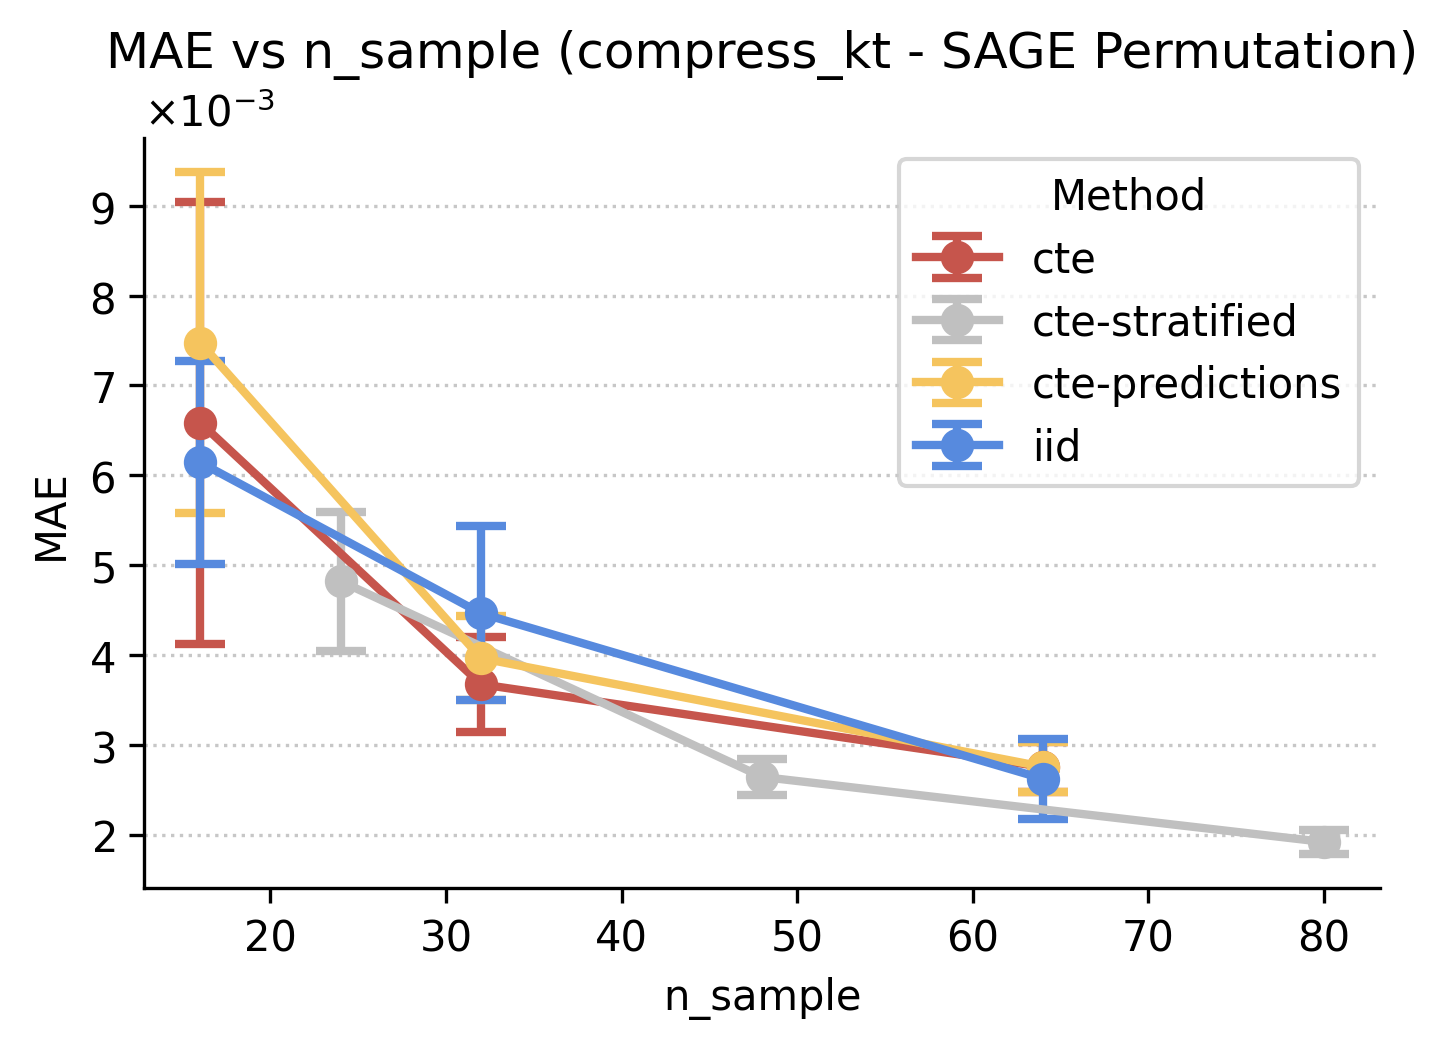

In [24]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

colors = {
    "iid_sage_permutation": "#578ade",
    "cte_sage_permutation": "#c6554c",
    "cte_stratified_sage_permutation": "#c0c0c0",
    "cte_with_predictions_sage_permutation": "#F5C45E",
}

for method in agg_df['method'].unique():
    method_data = agg_df[agg_df['method'] == method]
    x = method_data['n_sample']
    y = method_data['mean']
    yerr = method_data['std']
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method), 
        color=colors.get(method, None),  
        markersize=7, capsize=6, linewidth=2, capthick = 2
    )

ax.set_xlabel("n_sample")
ax.set_ylabel("MAE")
ax.set_title("MAE vs n_sample (compress_kt - SAGE Permutation)")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


SHAP + Kernel

In [25]:
times_cte_info_ = times_cte_info[
    times_cte_info['method'].isin([
        'cte_shap_kernel',
        'cte_with_predictions_shap_kernel',
        'cte_stratified_shap_kernel',
        'iid_shap_kernel'
    ])
]

In [26]:
ground_truth = values_gt['ground_truth_shap_kernel']

mae_list = []

method_indices = {method: 0 for method in values_cte.keys()}

for _, row in times_cte_info_.iterrows():
    method = row['method']
    
    current_index = method_indices[method]
    values_cte_ = values_cte[method][current_index]
    
    method_indices[method] += 1
    
    mae = metric_mae(values_cte_, ground_truth)
    mae_list.append(mae)  

times_cte_info_['mae'] = mae_list

times_cte_info_

,dataset,repeat,method,time_explanation,time_sample_choose,n_original,n_sample,g,mae
0,german,0,cte_shap_kernel,18.666594,0.002312,200,16,1,0.006813
4,german,0,cte_with_predictions_shap_kernel,20.993075,0.000218,200,16,1,0.006865
8,german,0,cte_stratified_shap_kernel,30.194832,0.000311,200,24,1,0.005915
12,german,0,iid_shap_kernel,22.259491,0.000039,200,16,1,0.007873
16,german,1,cte_shap_kernel,22.912032,0.000213,200,16,1,0.006631
20,german,1,cte_with_predictions_shap_kernel,23.416087,0.000223,200,16,1,0.006491
24,german,1,cte_stratified_shap_kernel,31.536093,0.000298,200,24,1,0.006078
28,german,1,iid_shap_kernel,23.278632,0.000037,200,16,1,0.009155
32,german,2,cte_shap_kernel,24.153932,0.000208,200,16,1,0.006716
36,german,2,cte_with_predictions_shap_kernel,23.737411,0.000207,200,16,1,0.006115


In [27]:
import pandas as pd
import matplotlib.pyplot as plt

agg_df = times_cte_info_.groupby(['method', 'n_sample']).agg(
    mean=('mae', 'mean'),
    std=('mae', 'std')
).reset_index()

method_labels = {
    "iid_shap_kernel": "iid",
    "cte_shap_kernel": "cte",
    "cte_with_predictions_shap_kernel": "cte-predictions",
    "cte_stratified_shap_kernel": "cte-stratified",
}

label=method_labels.get(method, method)

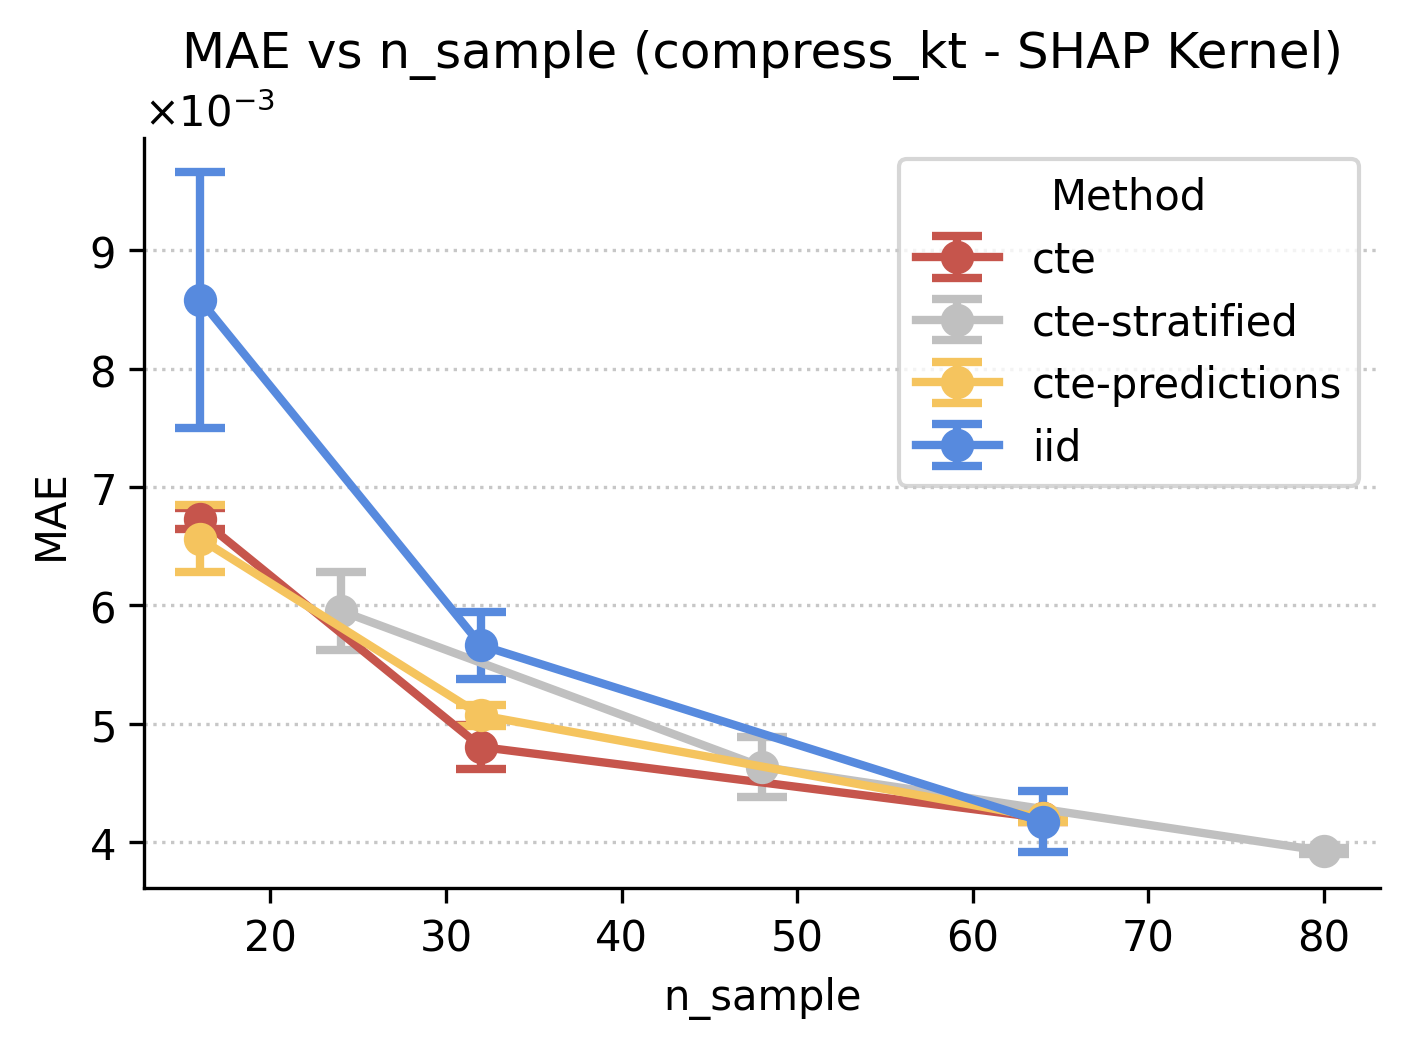

In [28]:
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(4.8, 3.6), dpi=300)

ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 2))

colors = {
    "iid_shap_kernel": "#578ade",
    "cte_shap_kernel": "#c6554c",
    "cte_stratified_shap_kernel": "#c0c0c0",
    "cte_with_predictions_shap_kernel": "#F5C45E",
}

for method in agg_df['method'].unique():
    method_data = agg_df[agg_df['method'] == method]
    x = method_data['n_sample']
    y = method_data['mean']
    yerr = method_data['std']
    ax.errorbar(
        x=x, y=y, yerr=yerr,
        fmt='o-', label=method_labels.get(method, method), 
        color=colors.get(method, None),  
        markersize=7, capsize=6, linewidth=2, capthick = 2
    )

ax.set_xlabel("n_sample")
ax.set_ylabel("MAE")
ax.set_title("MAE vs n_sample (compress_kt - SHAP Kernel)")
ax.legend(title="Method")
ax.grid(axis='y', linestyle='dotted', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
